In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             ConfusionMatrixDisplay, RocCurveDisplay)
import joblib
import matplotlib.pyplot as plt

ttc_data = pd.read_csv("Titanic-Dataset.csv")

/Users/prithvisadanand/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
ttc_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Select features/target
attributes = ttc_data[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
objectives = ttc_data["Survived"].astype(int)

# 4) Define feature groups
numerical_att = ["Age", "SibSp", "Parch", "Fare"]
categorical_att = ["Pclass", "Sex", "Embarked"]

print("Data uploaded and attributes choosen effectively.")

Data uploaded and attributes choosen effectively.


In [5]:
# Preprocessor: impute + scale/encode
preparation = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numerical_att),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_att)
])

print("preparation determined successfully.")

preparation determined successfully.


In [6]:
# Full pipeline: preprocess + model
pipe = Pipeline([
    ("prep", preparation),
    ("clf", LogisticRegression(max_iter=1000))
])

print("Pipeline is build successfully.")

Pipeline is build successfully.


In [9]:
# 7) Train/test split (stratify for class balance)
X_tr, X_te, y_tr, y_te = train_test_split(
    attributes, objectives, test_size=0.2, random_state=42, stratify=objectives
)

print(f"Data split completed.")
print(f"Training samples: {X_tr.shape[0]}")
print(f"Testing samples: {X_te.shape[0]}")

Data split completed.
Training samples: 712
Testing samples: 179


- The dataset was successfully classdified into training and testing subsets using an 80/20 split. 
- Hierarchy was applied to make sure the target variable (Survived) maintains proportional representation in both sets.  
- The process resulted in 712 training samples and 179 testing samples.

Classification report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

ROC-AUC: 0.8426877470355731


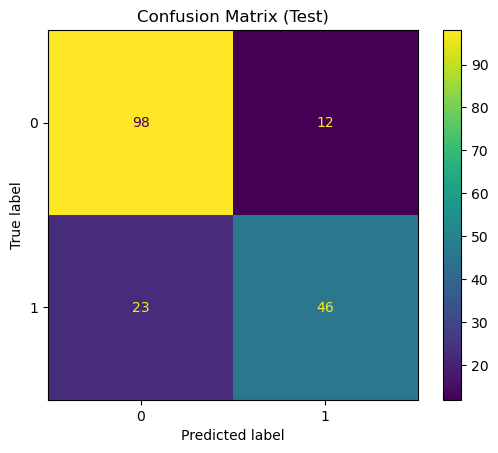

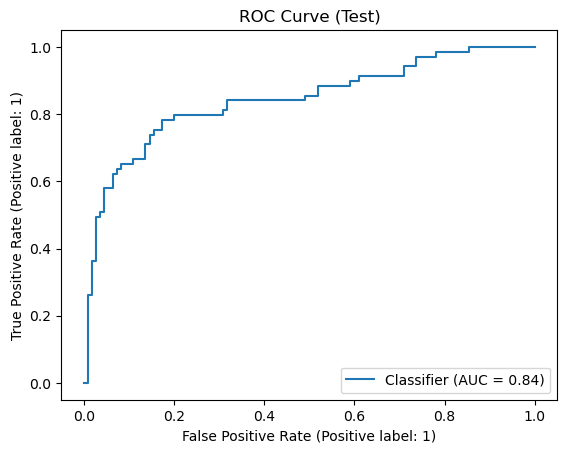

In [10]:
# Fit and evaluate
pipe.fit(X_tr, y_tr)
y_pred = pipe.predict(X_te)
y_proba = pipe.predict_proba(X_te)[:, 1]

print("Classification report:\n", classification_report(y_te, y_pred))
print("ROC-AUC:", roc_auc_score(y_te, y_proba))

ConfusionMatrixDisplay.from_predictions(y_te, y_pred)
plt.title("Confusion Matrix (Test)")
plt.show()

RocCurveDisplay.from_predictions(y_te, y_proba)
plt.title("ROC Curve (Test)")
plt.show()

- Confusion Matrix: This model successfully verified 98 passengers who did not survive (True Negatives) and 46 who did survive (True Positives), with 12 False Positives and 23 False Negatives. 
- ROC-AUC: The model achieved an AUC of 0.84, indicating a strong ability to distinguish between survivors and non-survivors.  
- Overall Performance: The combination of these visual metrics demonstrates that the Logistic Regression baseline is effectively learning patterns from the selected feature

In [13]:
# Cross-validation (5-fold ROC-AUC)
cv_auc = cross_val_score(pipe, attributes, objectives, cv=5, scoring="roc_auc")
print(f"CV ROC-AUC: {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}")

CV ROC-AUC: 0.848 +/- 0.014


***Stability:*** The 5-fold cross-validation ensued in an average ROC-AUC of 0.848.  

***Reliability:*** The low standard deviation of 0.014 announced that the model's performance is compatible across various subsets of the data, verifying the model is robust and not just overfitting to a single train-test split.

In [16]:
# Persist and reload
joblib.dump(pipe, "model.joblib")
pattern = joblib.load("model.joblib")

# Demonstration of loading and predicting
print("Case forecast:", pattern.predict(X_te.head(5)))

Case forecast: [0 0 0 0 1]


In [15]:
# 10) Persist and reload
joblib.dump(pipe, "model.joblib")
model = joblib.load("model.joblib")

# Demonstration of loading and predicting
print("Sample predictions:", model.predict(X_te.head(5)))

Sample predictions: [0 0 0 0 1]


The entire pipeline was successfully sequential and saved to model.joblib for future reclaim.  
The model was effectively refreshed from the disk and created predictions for the first five test cases, resulting in: [0 0 0 0 1].  